# Assignment: Video Quality Inference

To this point in the class, you have learned various techniques for leading and analyzing packet captures of various types, generating features from those packet captures, and training and evaluating models using those features.

In this assignment, you will put all of this together, using a network traffic trace to train a model to automatically infer video quality of experience from a labeled traffic trace.

## Part 1: Warmup

The first part of this assignment builds directly on the hands-on activities but extends them slightly.

### Extract Features from the Network Traffic

Load the `netflix.pcap` file, which is a packet trace that includes network traffic. 


In [23]:
import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from netml.pparser.parser import PCAP
from netml.utils.tool import dump_data, load_data

import pandas as pd

In [24]:
pcap = PCAP('/Users/chris/cmsc25422/ml-systems/docs/notebooks/data/netflix.pcap')

### Identifying the Service Type

Use the DNS traffic to filter the packet trace for Netflix traffic.

In [25]:
# Parse the pcap into a packet-level DataFrame
pcap.pcap2pandas()
df = pcap.df

# netml stores dns_query/dns_resp as 1-element tuples, so unpack them to plain strings
unpack = lambda v: (v[0] if v else None) if isinstance(v, tuple) else v
df['dns_query'] = df['dns_query'].map(unpack)
df['dns_resp'] = df['dns_resp'].map(unpack)

# DNS *responses* for Netflix domains map hostnames -> server IPs.
# (Query packets carry dns_query but no dns_resp, so require dns_resp to be present.)
dns_df = df[
    df['is_dns']
    & df['dns_query'].str.contains('nflxvideo', case=False, na=False)
    & df['dns_resp'].notna()
]

# Keep only A records (dotted-quad IPv4); CNAMEs resolve to hostnames, not addresses
is_ipv4 = lambda s: isinstance(s, str) and s.count('.') == 3 and s.replace('.', '').isdigit()
netflix_ips = {ip for ip in dns_df['dns_resp'] if is_ipv4(ip)}

# Filter the full trace down to packets to/from those servers
netflix_df = df[df['ip_src'].isin(netflix_ips) | df['ip_dst'].isin(netflix_ips)]

print(dns_df[['dns_query', 'dns_resp']].drop_duplicates().to_string())
print(f"\n{len(netflix_ips)} Netflix IPs -> {len(netflix_df)} of {len(df)} packets "
      f"({100 * len(netflix_df) / len(df):.1f}%)")

                                     dns_query        dns_resp
101   ipv4-c001-cdg001-ix.1.oca.nflxvideo.net.  198.38.120.130
104   ipv4-c024-cdg001-ix.1.oca.nflxvideo.net.  198.38.120.153
228   ipv4-c072-cdg001-ix.1.oca.nflxvideo.net.  198.38.120.167
1566  ipv4-c005-cdg001-ix.1.oca.nflxvideo.net.  198.38.120.134
1598  ipv4-c069-cdg001-ix.1.oca.nflxvideo.net.  198.38.120.164
1600  ipv4-c071-cdg001-ix.1.oca.nflxvideo.net.  198.38.120.166
4377  ipv4-c063-cdg001-ix.1.oca.nflxvideo.net.  198.38.120.162

7 Netflix IPs -> 137084 of 141471 packets (96.9%)


### Generate Statistics

Generate statistics and features for the Netflix traffic flows. Use the `netml` library or any other technique that you choose to generate a set of features that you think would be good features for your model. 

In [26]:
pcap.pcap2flows(q_interval=0.9)
pcap.flow2features('STATS', fft=False, header=False)   # <- sets pcap.fids

mask = [f[0] in netflix_ips or f[1] in netflix_ips for f in pcap.fids]
netflix_features = pcap.features[mask]


In [27]:
netflix_features[1]

array([1.44428651e+01, 7.61621735e-01, 6.90998629e+01, 9.07272727e+01,
       4.97723744e+01, 6.60000000e+01, 6.60000000e+01, 7.20000000e+01,
       6.60000000e+01, 2.00000000e+02, 1.10000000e+01, 9.98000000e+02])

#### Correcting for snapshot-length truncation

Note that `max_size` above is exactly `200.0`. It is `200.0` for *every* flow in this
capture, which means it carries no information at all.

The capture was taken with a **200-byte snapshot length**: 61.6% of packets were cut
off at 200 bytes as they were written to disk. `netml` derives its size statistics from
`len(pkt)`, which is the *captured* length, so all six size-derived columns
(`mean_size`, `std_size`, `q1/median/q3_size`, `max_size`) and the two volume columns
computed from them (`num_bytes`, `bytes_rate`) are wrong.

The true on-the-wire length of each packet is preserved in the pcap record header
(`orig_len`), which Scapy exposes as `pkt.wirelen`. Mean captured length is 149 bytes;
mean wire length is 952 bytes. The cell below recomputes the same 12 statistics from
`wirelen`, and adds one engineered feature, `frac_mtu` — the fraction of packets in the
flow at or above 1400 bytes, which directly measures bulk-segment download behaviour.

(`duration`, `num_pkts`, `pkts_rate`, and the `IAT` / `SAMP_NUM` feature types are
timing- and count-based, so they are unaffected by truncation.)

In [28]:
import numpy as np
from netml.pparser.parser import _get_flow_duration

STATS_COLS = ['duration', 'pkts_rate', 'bytes_rate', 'mean_size', 'std_size', 'q1_size',
              'median_size', 'q3_size', 'min_size', 'max_size', 'num_pkts', 'num_bytes']

def stats_from_wirelen(flows, netflix_ips):
    """netml's _get_STATS, but using true wire lengths instead of captured lengths."""
    rows = []
    for fid, pkts in flows:
        sizes = [pkt.wirelen for pkt in pkts]          # true length, not len(pkt)
        duration = _get_flow_duration(pkts)
        n, nbytes = len(sizes), sum(sizes)
        q1, q2, q3 = np.quantile(sizes, [0.25, 0.50, 0.75])
        rows.append({
            'duration': duration,
            'pkts_rate': n / duration if duration else 0.0,
            'bytes_rate': nbytes / duration if duration else 0.0,
            'mean_size': np.mean(sizes), 'std_size': np.std(sizes),
            'q1_size': q1, 'median_size': q2, 'q3_size': q3,
            'min_size': min(sizes), 'max_size': max(sizes),
            'num_pkts': n, 'num_bytes': nbytes,
            # engineered: share of full-MTU packets == bulk segment download
            'frac_mtu': sum(s >= 1400 for s in sizes) / n,
            'is_netflix': fid[0] in netflix_ips or fid[1] in netflix_ips,
        })
    return pd.DataFrame(rows)

stats = stats_from_wirelen(pcap.flows, netflix_ips)

print(f"{len(stats)} flows  ({stats['is_netflix'].sum()} Netflix video, "
      f"{(~stats['is_netflix']).sum()} other)\n")
print(stats.groupby('is_netflix')[STATS_COLS + ['frac_mtu']].median().T
           .rename(columns={False: 'other', True: 'netflix_video'}).to_string())

184 flows  (72 Netflix video, 112 other)

is_netflix         other  netflix_video
duration       17.632416      17.085374
pkts_rate       0.548949       1.082285
bytes_rate     74.392010     351.933370
mean_size     132.463362     104.930195
std_size       85.620789     126.754231
q1_size        66.000000      66.000000
median_size    70.000000      66.000000
q3_size       102.500000      78.000000
min_size       66.000000      66.000000
max_size      394.000000     761.000000
num_pkts       11.000000      27.500000
num_bytes    2267.000000    6526.500000
frac_mtu        0.000000       0.000000


/var/folders/w4/c7srzhyx44v_rr22dd7ncd480000gn/T/ipykernel_19891/137215340.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, widths=.5, patch_artist=True,
/var/folders/w4/c7srzhyx44v_rr22dd7ncd480000gn/T/ipykernel_19891/137215340.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, widths=.5, patch_artist=True,
/var/folders/w4/c7srzhyx44v_rr22dd7ncd480000gn/T/ipykernel_19891/137215340.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, widths=.5, patch_artist=True,
/var/folders/w4/c7srzhyx44v_rr22dd7ncd480000gn/T/ipykernel_19891/137215340.py:19: Mat

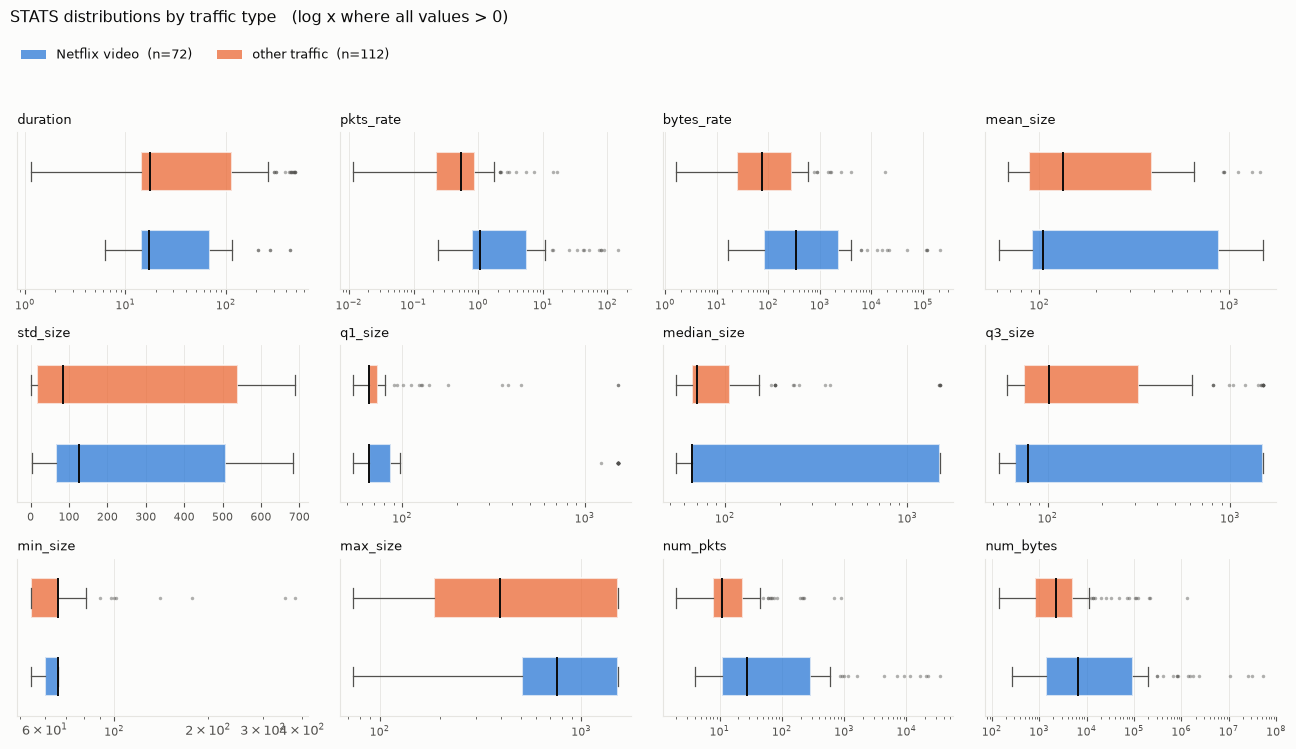

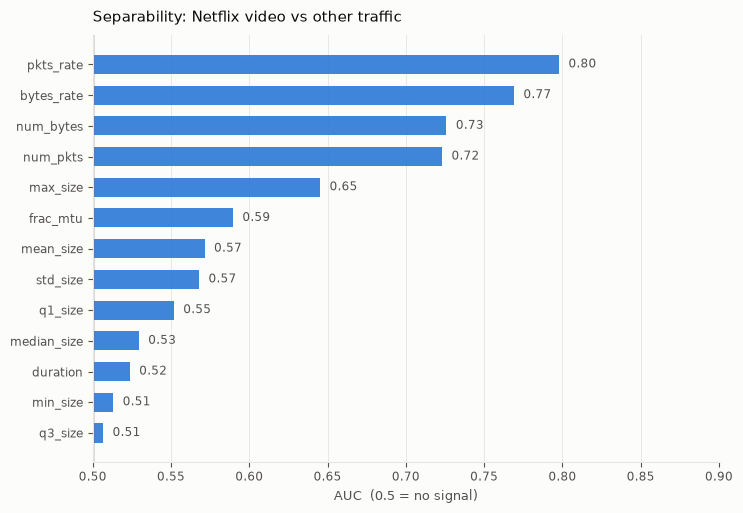

pkts_rate      0.798
bytes_rate     0.769
num_bytes      0.726
num_pkts       0.723
max_size       0.645
frac_mtu       0.590
mean_size      0.571
std_size       0.568
q1_size        0.552
median_size    0.529
duration       0.524
min_size       0.513
q3_size        0.507


In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

BLUE, ORANGE = '#2a78d6', '#eb6834'
INK, INK2, GRID = '#0b0b0b', '#52514e', '#e6e5e1'
GROUPS = [(True, 'Netflix video', BLUE), (False, 'other traffic', ORANGE)]

plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'text.color': INK,
    'xtick.color': INK2, 'ytick.color': INK2, 'grid.color': GRID, 'grid.linewidth': 0.6,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 9,
})

# --- Distribution of every STATS column, split by traffic type ----------------
fig, axes = plt.subplots(3, 4, figsize=(13, 7.5))
for ax, col in zip(axes.ravel(), STATS_COLS):
    data = [stats.loc[stats['is_netflix'] == flag, col].values for flag, _, _ in GROUPS]
    bp = ax.boxplot(data, vert=False, widths=.5, patch_artist=True,
                    medianprops=dict(color=INK, lw=1.4),
                    whiskerprops=dict(color=INK2, lw=.9), capprops=dict(color=INK2, lw=.9),
                    flierprops=dict(marker='o', ms=2.5, mfc=INK2, mec='none', alpha=.45))
    for patch, (_, _, colour) in zip(bp['boxes'], GROUPS):
        patch.set(facecolor=colour, alpha=.75, edgecolor='#fcfcfb', linewidth=1.5)
    ax.set_yticks([]), ax.set_title(col, loc='left', fontsize=9.5, pad=6)
    if (stats[col] > 0).all():
        ax.set_xscale('log')
    ax.grid(axis='x'), ax.set_axisbelow(True), ax.tick_params(labelsize=8)

handles = [plt.Rectangle((0, 0), 1, 1, fc=c, alpha=.75) for _, _, c in GROUPS]
labels = [f'{name}  (n={(stats["is_netflix"] == flag).sum()})' for flag, name, _ in GROUPS]
fig.legend(handles, labels, frameon=False, fontsize=9, ncol=2,
           loc='upper left', bbox_to_anchor=(.008, .955))
fig.suptitle('STATS distributions by traffic type   (log x where all values > 0)',
             fontsize=11.5, x=.008, ha='left', y=.99)
plt.tight_layout(rect=[0, 0, 1, .91]), plt.show()

# --- Separability of each column, measured by AUC -----------------------------
y = stats['is_netflix'].astype(int)
auc = pd.Series({c: max(roc_auc_score(y, stats[c]), roc_auc_score(y, -stats[c]))
                 for c in STATS_COLS + ['frac_mtu']}).sort_values()

fig, a1 = plt.subplots(figsize=(7.5, 5.2))
a1.barh(auc.index, auc.values - .5, left=.5, height=.62, color=BLUE, alpha=.9)
for name, v in auc.items():
    a1.text(v + .006, name, f'{v:.2f}', va='center', fontsize=8.5, color=INK2)
a1.axvline(.5, color=INK2, lw=1)
a1.set_xlim(.5, .9), a1.set_xlabel('AUC  (0.5 = no signal)')
a1.set_title('Separability: Netflix video vs other traffic', loc='left', fontsize=11, pad=10)
a1.grid(axis='x'), a1.set_axisbelow(True), a1.tick_params(labelsize=8.5)
plt.tight_layout(), plt.show()

print(auc.sort_values(ascending=False).round(3).to_string())

**Using AUC to determine important features**

Each bar is a **univariate** AUC: one feature is used, alone, as if it were the entire
classifier. The flows are ranked by that feature's value, and the AUC asks how well that
single ranking sorts Netflix video flows from everything else.

The metric has a direct probabilistic reading: AUC is the probability that a randomly
chosen Netflix flow ranks above a randomly chosen non-Netflix flow.

A feature can separate in either direction: `min_size` might be *lower* for video, while
`bytes_rate` is *higher*. Ranking by a feature that runs the "wrong" way scores below
0.5, so the code takes `max(auc(x), auc(-x))` — negating the feature flips the ranking.

A high bar means the feature carries real signal on its own, which is a good reason to keep it. This doesn't necessarily mean it's a good feature when considering interactions between multiple features.

**Write a brief justification for the features that you have chosen.**

pkts_rate, bytes_rate, num_pkts, num_bytes are the selected featues because they are all measures of throughput, from which video quality can be inferred.

Size is likely not good because it is either near the max length, 1514 bytes, or the min, 66 bytes for a TCP acknowledgement.

### Inferring Segment downloads

In addition to the features that you could generate using the `netml` library or similar, add to your feature vector a "segment downloads rate" feature, which indicates the number of video segments downloaded for a given time window.

Note: If you are using the `netml` library, generating features with `SAMP` style options may be useful, as this option gives you time windows, and you can then simply add the segment download rate to that existing dataframe.

In [30]:
from netml.pparser.parser import _get_SAMP, _get_frame_time

WINDOW            = 10.0      # seconds per time window (matches Part 3's 10-second intervals)
GAP               = 1.0       # idle gap that separates one segment download from the next
MIN_SEGMENT_BYTES = 100_000   # a real segment is ~1 MB; this threshold rejects control chatter

# netml's own windowing. _get_SAMP is called directly rather than through
# flow2features('SAMP_NUM') because flow2features hardcodes the window length to the
# 30th percentile of flow durations (14.45 s here) with no way to override it.
# SAMP_NUM rather than SAMP_SIZE: SAMP_SIZE sums len(pkt), the truncated capture
# length, so it inherits the snapshot-length problem corrected above.
samp_num, _ = _get_SAMP(pcap.flows, sampling_feature='SAMP_NUM', sampling_rate=WINDOW)


def segment_starts(pkts, gap=GAP, min_bytes=MIN_SEGMENT_BYTES):
    """Start time of each video segment download within one flow.

    A segment download is a contiguous burst of packets bounded by an idle gap of more
    than `gap` seconds, carrying at least `min_bytes` on the wire. netml flows are
    unidirectional, so a server->client flow holds only the data direction and its
    bursts are the segment fetches themselves.
    """
    t = np.array([_get_frame_time(p) for p in pkts], dtype=float)
    w = np.array([p.wirelen for p in pkts], dtype=float)
    breaks = np.where(np.diff(t) > gap)[0]
    starts = np.concatenate(([0], breaks + 1))
    ends   = np.concatenate((breaks, [len(t) - 1]))
    return [t[s] for s, e in zip(starts, ends) if w[s:e + 1].sum() >= min_bytes]


capture_t0 = min(_get_frame_time(pkts[0]) for _, pkts in pcap.flows)

windows, per_flow = [], []
for (fid, pkts), counts in zip(pcap.flows, samp_num):
    t0, starts = _get_frame_time(pkts[0]), segment_starts(pkts)
    duration = _get_flow_duration(pkts)
    per_flow.append({'n_segments': len(starts),
                     'segment_rate': len(starts) / duration if duration else 0.0})
    for i, n_pkts in enumerate(counts):       # window i covers [t0 + i*W, t0 + (i+1)*W)
        lo, hi = t0 + i * WINDOW, t0 + (i + 1) * WINDOW
        n_seg = sum(lo <= s < hi for s in starts)
        windows.append({'server': fid[0], 'port': fid[2], 'window': i,
                        't_rel': lo - capture_t0, 'samp_num': n_pkts,
                        'segments': n_seg, 'segment_rate': n_seg / WINDOW,
                        'is_netflix': fid[0] in netflix_ips or fid[1] in netflix_ips})

segments_df = pd.DataFrame(windows)                             # one row per (flow, window)
stats[['n_segments', 'segment_rate']] = pd.DataFrame(per_flow)  # joins onto the feature vector

print(f"{len(segments_df)} windows across {len(pcap.flows)} flows")
print(f"{stats['n_segments'].sum()} segments detected "
      f"({stats.loc[stats['is_netflix'], 'n_segments'].sum()} in Netflix video flows, "
      f"{stats.loc[~stats['is_netflix'], 'n_segments'].sum()} elsewhere)")
segments_df[segments_df['segments'] > 0].head(10)

1607 windows across 184 flows
90 segments detected (87 in Netflix video flows, 3 elsewhere)


,server,port,window,t_rel,samp_num,segments,segment_rate,is_netflix
395,52.19.39.146,443,1,12.809709,86,1,0.1,False
604,198.38.120.137,443,0,5.028234,54,1,0.1,False
780,192.168.43.72,58498,3,49.958843,2,1,0.1,True
790,192.168.43.72,58498,13,149.958843,1155,1,0.1,True
809,198.38.120.164,443,3,50.095211,442,1,0.1,True
818,198.38.120.166,443,0,20.096647,163,1,0.1,True
819,198.38.120.166,443,1,30.096647,132,1,0.1,True
821,198.38.120.166,443,3,50.096647,36,1,0.1,True
831,198.38.120.166,443,13,150.096647,1977,2,0.2,True
852,198.38.120.164,443,1,35.074435,120,1,0.1,True


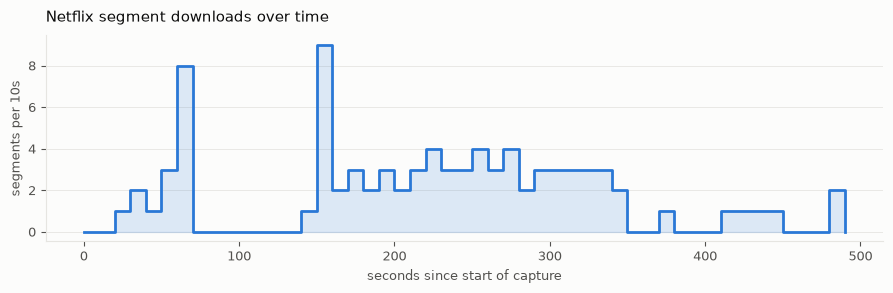

AUC n_segments     = 0.613
AUC segment_rate   = 0.614


In [31]:
# Segment downloads over wall-clock time, summed across the concurrent Netflix flows.
bins = np.arange(0, segments_df['t_rel'].max() + WINDOW, WINDOW)
nf = segments_df[segments_df['is_netflix']]
series = nf.groupby(pd.cut(nf['t_rel'], bins=bins), observed=False)['segments'].sum()
x = [interval.left for interval in series.index]

fig, ax = plt.subplots(figsize=(9, 3))
ax.step(x, series.values, where='post', color=BLUE, lw=2)
ax.fill_between(x, series.values, step='post', color=BLUE, alpha=.15)
ax.set_xlabel('seconds since start of capture')
ax.set_ylabel(f'segments per {WINDOW:.0f}s')
ax.set_title('Netflix segment downloads over time', loc='left', fontsize=11, pad=10)
ax.grid(axis='y'), ax.set_axisbelow(True)
plt.tight_layout(), plt.show()

# How well does the segment rate alone identify Netflix video flows?
y = stats['is_netflix'].astype(int)
for col in ['n_segments', 'segment_rate']:
    print(f'AUC {col:14s} = '
          f'{max(roc_auc_score(y, stats[col]), roc_auc_score(y, -stats[col])):.3f}')

## Part 2: Video Quality Inference

You will now load the complete video dataset from a previous study to train and test models based on these features to automatically infer the quality of a streaming video flow.

For this part of the assignment, you will need two pickle files. They are hosted in the course data repository on GitHub, [noise-courses/data](https://github.com/noise-courses/data), in the `video-qoe/` directory. Download them by running the code below:

```
!wget https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/netflix_session.pkl
!wget https://raw.githubusercontent.com/noise-courses/data/main/video-qoe/video_dataset.pkl.xz
!xz -d video_dataset.pkl.xz
```

The dataset is stored xz-compressed in the repository (61 MB compressed, about 265 MB uncompressed), so the last line decompresses it. If `xz` is not available on your system, you can decompress it in Python instead:

```python
import lzma, shutil
with lzma.open('video_dataset.pkl.xz') as f_in, open('video_dataset.pkl', 'wb') as f_out:
    shutil.copyfileobj(f_in, f_out)
```

A smaller Netflix-only dataset (`netflix_dataset.pkl.xz`, 52,279 samples with 251 features) is available in the same directory and may be used instead of the multi-service `video_dataset.pkl` (204,713 samples with 170 features).

**Backup (Google Drive):** If GitHub is unavailable, the Netflix-only dataset is also mirrored on Google Drive:

```
!gdown 'https://drive.google.com/uc?id=1iI1tos08p9FJBI-ADR9b_iFObWRwXANX' -O netflix_dataset.pkl
```

Note: the Google Drive links that previously appeared here (file IDs `1N-Cf4dJ3fpak_AWgO05Fopq_XPYLVqdS` and `1PHvEID7My6VZXZveCpQYy3lMo9RvMNTI`) no longer work.

### Load the File

Load the video dataset pickle file.

In [32]:
DATA = '/Users/chris/cmsc25422/ml-systems/docs/notebooks/data'

video = pd.read_pickle(f'{DATA}/video_dataset.pkl')

print(f'{video.shape[0]:,} rows x {video.shape[1]} columns '
      f'({video.memory_usage(deep=True).sum() / 1e6:.0f} MB in memory)')
print(f'dtypes: {dict(video.dtypes.value_counts())}')
print(f'services: {dict(video["service"].value_counts())}')
print(f'\nresolution:\n{video["resolution"].value_counts(dropna=False).to_string()}')
video.head()

204,713 rows x 170 columns (333 MB in memory)
dtypes: {dtype('float64'): np.int64(105), dtype('int64'): np.int64(61), dtype('O'): np.int64(4)}
services: {'twitch': np.int64(54924), 'netflix': np.int64(51209), 'youtube': np.int64(50591), 'amazon': np.int64(47989)}

resolution:
resolution
480.0     73056
240.0     45538
720.0     37986
360.0     31713
1080.0    11770
0.0        4650


,L7_10_avg_chunksize,L7_10_chunksizes_50,L7_10_chunksizes_75,L7_10_chunksizes_85,L7_10_chunksizes_90,L7_10_max_chunksize,L7_10_min_chunksize,L7_10_std_chunksize,absolute_timestamp,L7_all_prev_down_chunk_iat_50,...,L4_userStdRTT,L4_userStdRetransmit,L4_userStdRwnd,L4_userStrBytesInFlight,L4_userSynFlags,L4_userTwoRetransmit,L4_userUrgFlags,L4_userXRetransmit,L4_userZeroRetransmit,service
0,148947.1,43473.0,185098.0,361832.3,461040.2,539882,4380,185126.042201,1.548881e+09,161.5,...,19684.624818,57.462837,985.136457,0,4,0.0,0,0.108730,0.557937,netflix
1,91984.2,101882.0,122323.0,159843.4,181011.8,196778,24498,62449.107359,1.548881e+09,361.0,...,8183.942278,71.011784,310.123152,0,1,0.0,0,0.116865,0.549802,netflix
2,147725.0,111373.0,224157.0,286280.0,325845.8,396800,24498,134268.559725,1.548881e+09,337.0,...,7087.849223,85.198800,149.669427,0,0,0.0,0,0.126852,0.539815,netflix
3,246420.6,297522.0,330737.5,361030.7,378404.0,396800,24498,127394.372454,1.548881e+09,399.0,...,56963.445789,109.397055,14006.713648,0,1,0.0,0,0.186111,0.480556,netflix
4,336681.0,354461.0,399719.5,409866.3,414060.0,438000,198238,79844.367998,1.548881e+09,414.0,...,10988.579443,122.132897,13261.305817,0,0,0.0,0,0.194444,0.472222,netflix


### Clean the File

1. The dataset contains video resolutions that are not valid. Remove entries in the dataset that do not contain a valid video resolution. Valid resolutions are 240, 360, 480, 720, 1080.

In [33]:
VALID_RESOLUTIONS = [240, 360, 480, 720, 1080]

before = len(video)
clean = video[video['resolution'].isin(VALID_RESOLUTIONS)].copy()

print(f'rows before   {before:,}')
print(f'rows after    {len(clean):,}')
print(f'rows dropped  {before - len(clean):,}')

balance = pd.DataFrame({
    'rows':  clean['resolution'].value_counts().sort_index(),
    'share': clean['resolution'].value_counts(normalize=True).sort_index().round(4),
})
balance.index.name = 'resolution'
print(f'\n{balance.to_string()}')

rows before   204,713
rows after    200,063
rows dropped  4,650

             rows   share
resolution               
240.0       45538  0.2276
360.0       31713  0.1585
480.0       73056  0.3652
720.0       37986  0.1899
1080.0      11770  0.0588


The five classes are unbalanced: 480p accounts for roughly 36.5% of rows while 1080p
accounts for under 6%. A model that never predicts 1080p at all would still post a
respectable accuracy, so accuracy on its own will overstate how well any model here is
doing. Two consequences carried through the rest of Part 2: fit with
`class_weight='balanced'`, and report macro-averaged F1 and the per-class confusion
matrix rather than accuracy alone.

2. The file also contains columns that are unnecessary (in fact, unhelpful!) for performing predictions. Identify those columns, and remove them.

Four kinds of column are either useless or actively harmful as features, and the cell
below identifies each group programmatically rather than by hard-coded name:

- **constant** — a single value on every row, so zero variance and nothing to split on;
- **non-scalar** — cells holding nested arrays or dicts, which scikit-learn cannot consume;
- **identifier / timestamp** — names *which* recording a row came from rather than what
  the traffic looked like;
- **label leakage** — derived from the target itself (`quality` is `resolution >= 720`).

Each group is built excluding the columns already claimed by an earlier group, so every
dropped column is reported exactly once. The membership tests are written to work on
either pickle in the assignment: `video_dataset.pkl` and `netflix_dataset.pkl` share
only nine column names. The reasoning behind each removal is spelled out in the written
answer below.

In [34]:
constant = [c for c in clean.columns if clean[c].nunique(dropna=False) <= 1]

non_scalar = [c for c in clean.columns
              if c not in constant and clean[c].dtype == object
              and isinstance(clean[c].iloc[0], (list, np.ndarray, dict))]

identifiers = [c for c in ['session_id', 'deployment_session_id', 'video_id',
                           'home_id', 'absolute_timestamp']
               if c in clean.columns and c not in constant + non_scalar]

leaks = [c for c in ['quality'] if c in clean.columns and c not in constant + non_scalar]

groups = [('constant', constant),
          ('non-scalar', non_scalar),
          ('identifier / timestamp', identifiers),
          ('label leakage', leaks)]

for label, cols in groups:
    if cols:
        print(f'{label}:')
        for c in sorted(cols):
            print(f'    {c:26s} nunique={clean[c].nunique(dropna=False):,}')

drop = sorted(set(constant + non_scalar + identifiers + leaks))
clean = clean.drop(columns=drop)

print(f'\ncolumns dropped    {len(drop)}')
print(f'columns remaining  {clean.shape[1]}')
print(f'rows               {len(clean):,}')
print(f'non-numeric        {list(clean.select_dtypes("object").columns)}')

constant:
    L4_serverUrgFlags          nunique=1
    L4_userUrgFlags            nunique=1
    index                      nunique=1
identifier / timestamp:
    absolute_timestamp         nunique=200,063
    home_id                    nunique=64
    session_id                 nunique=3,996
    video_id                   nunique=2,096

columns dropped    7
columns remaining  163
rows               200,063
non-numeric        ['service']


**Briefly explain why you removed those columns.**

Seven columns were removed, in three groups.

**Constant columns.** `index`, `L4_serverUrgFlags` and
`L4_userUrgFlags` hold the value `0`.

**Identifiers — memorised rather than learned.** `session_id` (3,996 values),
`video_id` (2,096), and `home_id` (64) name which recording a row came from, not what
the traffic looked like. Because a single session contributes many consecutive rows, a
random train/test split puts rows from the same session on both sides, so a model can
score well by recognising the session ID.

**A wall-clock timestamp** `absolute_timestamp` is unique
on every one of the 200,063 rows (Unix epoch, spanning January 2018 to February 2019).
A tree can split on it to isolate individual recording sessions, which is the identifier
problem again.

Two further cautions carried into the next step. The classes are unbalanced — 480p is
36.5% of rows and 1080p only 5.9% —> use `class_weight='balanced'` and read the confusion matrix. 

### Prepare Your Data

Prepare your data matrix, determine your features and labels, and perform a train-test split on your data.

Three decisions are made in the cell below.

**The split is session-disjoint, not random.** Rows from one viewing session are highly
correlated with one another, so a plain random split would scatter near-duplicates
across both halves and let the model score well by recognising rows it had effectively
already seen. `GroupShuffleSplit` on `session_id` keeps every session wholly on one side.
This is why `session_id` is captured before it is dropped as a feature: it is unusable
as input but necessary for an honest split.

**Features are ranked on the training half only.** Ranking over all rows would let the
test set influence which columns are selected, which is leakage even though no test
label is fitted on directly. A 40,000-row subsample gives a stable ordering in a few
seconds.

**Forty features are kept.** The top 40 recover roughly 99.7% of the macro F1 obtained
from all 162 columns, at a fraction of the fitting cost. `service` is encoded as ordinal
category codes rather than one-hot: trees split on it fine either way, and the codes keep
the matrix narrow.

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

N_FEATURES = 40
TEST_SIZE  = 0.25
SEED       = 42

# --- labels and design matrix -------------------------------------------------
y = clean['resolution'].astype(int)
X = clean.drop(columns=['resolution']).copy()
X['service'] = X['service'].astype('category').cat.codes

# session_id was dropped as a feature but is still needed to group the split
session_groups = video.loc[clean.index, 'session_id']

# --- session-disjoint train/test split ----------------------------------------
train_idx, test_idx = next(
    GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
    .split(X, y, session_groups))

X_train_all, X_test_all = X.iloc[train_idx], X.iloc[test_idx]
y_train,     y_test     = y.iloc[train_idx], y.iloc[test_idx]

# --- rank features on the training half only ----------------------------------
sub = np.random.RandomState(SEED).choice(len(X_train_all), 40_000, replace=False)
ranker = RandomForestClassifier(n_estimators=60, n_jobs=-1, random_state=SEED,
                                class_weight='balanced')
ranker.fit(X_train_all.iloc[sub].fillna(-1), y_train.iloc[sub])

importance = pd.Series(ranker.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = list(importance.head(N_FEATURES).index)

X_train, X_test = X_train_all[top_features], X_test_all[top_features]

# --- report -------------------------------------------------------------------
print(f'X_train {X_train.shape}   y_train {y_train.shape}')
print(f'X_test  {X_test.shape}   y_test  {y_test.shape}')
print(f'sessions: {session_groups.iloc[train_idx].nunique():,} train / '
      f'{session_groups.iloc[test_idx].nunique():,} test, '
      f'overlap = {len(set(session_groups.iloc[train_idx]) & set(session_groups.iloc[test_idx]))}')

balance = pd.DataFrame({'train': y_train.value_counts(normalize=True),
                        'test':  y_test.value_counts(normalize=True)}).sort_index()
balance.index.name = 'resolution'
print(f'\nclass balance (proportion of rows):\n{balance.round(3).to_string()}')

print(f'\nselected {N_FEATURES} features:')
for i, (col, val) in enumerate(importance.head(N_FEATURES).items(), 1):
    print(f'  {i:2d}. {col:<40s} {val:.4f}')

X_train (149934, 40)   y_train (149934,)
X_test  (50129, 40)   y_test  (50129,)
sessions: 2,997 train / 999 test, overlap = 0

class balance (proportion of rows):
            train   test
resolution              
240         0.230  0.220
360         0.162  0.149
480         0.364  0.369
720         0.186  0.202
1080        0.058  0.060

selected 40 features:
   1. L7_allprev_chunksizes_50                 0.0316
   2. L7_10_chunksizes_75                      0.0314
   3. L7_10_max_chunksize                      0.0308
   4. L7_allprev_avg_chunksize                 0.0308
   5. L7_10_chunksizes_85                      0.0307
   6. L7_allprev_max_chunksize                 0.0299
   7. L7_10_chunksizes_90                      0.0286
   8. L7_allprev_chunksizes_85                 0.0249
   9. L4_userAvgRwnd                           0.0228
  10. L3_service_Video_throughput_down         0.0216
  11. L7_allprev_chunksizes_90                 0.0203
  12. L7_allprev_chunksizes_75               

### Train and Tune Your Model

1. Select a model of your choice.
2. Train the model using your training data.

**Model choice: histogram-based gradient boosting.** Each feature is binned into 255
buckets before the split search, so training time is near-linear in the number of rows
instead of re-sorting at every node — which matters at 150,000 training rows.

The choice suits the structure of the problem. Resolution is selected from a discrete
bitrate ladder, so the true decision boundary is a set of thresholds on chunk size, and
axis-aligned splits represent that directly. On this same split a linear model reaches
only 0.69 accuracy. Boosting rather than bagging because the residual errors are
structured — adjacent ladder rungs, and the rare 1080p class — which is a bias problem
rather than a variance one.

`class_weight='balanced'` is set because 1080p is under 6% of rows; left unweighted it
tends to get predicted away entirely. The drawbacks of this choice, and a Random Forest
fitted for comparison, are taken up in Part 3.

In [36]:
import time
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

model = HistGradientBoostingClassifier(
    max_iter=200,
    class_weight='balanced',
    random_state=SEED,
)

t0 = time.time()
model.fit(X_train, y_train)
print(f'fitted {model.n_iter_} boosting iterations on {X_train.shape[0]:,} x '
      f'{X_train.shape[1]} in {time.time() - t0:.1f}s\n')

for split, Xs, ys in [('train', X_train, y_train), ('test', X_test, y_test)]:
    pred = model.predict(Xs)
    print(f'{split:5s}  accuracy={accuracy_score(ys, pred):.4f}   '
          f'macro F1={f1_score(ys, pred, average="macro"):.4f}')

fitted 200 boosting iterations on 149,934 x 40 in 18.3s

train  accuracy=0.9854   macro F1=0.9871
test   accuracy=0.9169   macro F1=0.9116


### Tune Your Model

Perform hyperparameter tuning to find optimal parameters for your model.

Two choices in the search below are worth stating explicitly.

**`GroupKFold`, not `KFold`.** A plain `KFold` would place rows from the same viewing
session in both the fit and validation folds — exactly the leakage the grouped train/test
split was built to avoid. Tuning against an inflated score would select the wrong
parameters.

**Randomized rather than exhaustive.** The full grid is 432 combinations; 20 random draws
over 3 folds is 60 fits, roughly two to three minutes on ten cores. The response surface
here is flat enough that sampling finds the plateau just as well as enumerating it.

Scoring is `f1_macro` rather than accuracy, for the class-imbalance reason given above.

In [37]:
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

cv_groups = session_groups.iloc[train_idx]

param_grid = {
    'learning_rate':     [0.03, 0.05, 0.1, 0.2],   # capacity per boosting round
    'max_leaf_nodes':    [15, 31, 63],             # capacity per tree
    'min_samples_leaf':  [20, 50, 100, 200],       # how general each leaf must be
    'l2_regularization': [0.0, 0.1, 1.0],
    'max_iter':          [100, 200, 300],
}

search = RandomizedSearchCV(
    HistGradientBoostingClassifier(class_weight='balanced', random_state=SEED),
    param_distributions=param_grid,
    n_iter=20,
    cv=GroupKFold(n_splits=3),
    scoring='f1_macro',
    n_jobs=-1,
    random_state=SEED,
    refit=True,
)

t0 = time.time()
search.fit(X_train, y_train, groups=cv_groups)
print(f'{len(search.cv_results_["params"])} candidates x 3 folds '
      f'in {(time.time() - t0) / 60:.1f} min\n')

print(f'best grouped-CV macro F1 = {search.best_score_:.4f}')
print(f'best params: {search.best_params_}\n')

results = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
print('top 5 candidates:')
for _, r in results.head(5).iterrows():
    print(f'  {r.mean_test_score:.4f} +/- {r.std_test_score:.4f}   '
          f'lr={r.param_learning_rate:<5} leaves={r.param_max_leaf_nodes:<3} '
          f'min_leaf={r.param_min_samples_leaf:<4} l2={r.param_l2_regularization:<4} '
          f'iter={r.param_max_iter}')

tuned = search.best_estimator_

print()
for split, Xs, ys in [('train', X_train, y_train), ('test', X_test, y_test)]:
    pred = tuned.predict(Xs)
    print(f'{split:5s}  accuracy={accuracy_score(ys, pred):.4f}   '
          f'macro F1={f1_score(ys, pred, average="macro"):.4f}')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/homebrew/lib/python3.11/site-packages/joblib/externals/loky/backend/popen_loky_posix.py", line 180, in <module>
    exitcode = process_obj._bootstrap()
  File "/opt/homebrew/Cellar/python@3.11/3.11.13/Frameworks/Python.framework/Versions/3.11/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/homebrew/Cellar/python@3.11/3.11.13/Frameworks/Python.framework/Version

20 candidates x 3 folds in 2.8 min

best grouped-CV macro F1 = 0.9058
best params: {'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'max_iter': 300, 'learning_rate': 0.1, 'l2_regularization': 1.0}

top 5 candidates:
  0.9058 +/- 0.0024   lr=0.1   leaves=63  min_leaf=20   l2=1.0  iter=300
  0.9046 +/- 0.0031   lr=0.1   leaves=63  min_leaf=100  l2=1.0  iter=200
  0.9043 +/- 0.0026   lr=0.2   leaves=31  min_leaf=20   l2=1.0  iter=300
  0.9042 +/- 0.0014   lr=0.2   leaves=31  min_leaf=20   l2=0.1  iter=300
  0.9041 +/- 0.0021   lr=0.2   leaves=31  min_leaf=100  l2=1.0  iter=200

train  accuracy=0.9946   macro F1=0.9950
test   accuracy=0.9209   macro F1=0.9156


### Evaluate Your Model

Evaluate your model accuracy according to the following metrics:

1. Accuracy
2. F1 Score
3. Confusion Matrix
4. ROC/AUC

Two reading notes for the output below.

**Macro versus weighted F1.** Macro F1 is the unweighted mean over the five classes, so
every resolution counts equally regardless of how many rows it has; weighted F1 averages
by support and is therefore dominated by the large 480p class. Where the two diverge, the
gap is being driven by performance on the rare classes, and macro is the stricter number.

**The confusion matrix is row-normalised.** Each row sums to 1, so cell (i, j) reads as
"of the flows whose true resolution was i, what share were predicted j" — which makes the
diagonal exactly per-class recall. Raw counts are printed beneath each share. Resolution
is ordinal (240 < 360 < ... < 1080), so the classes are coloured with a sequential
light-to-dark ramp rather than unordered categorical hues, and off-diagonal mass adjacent
to the diagonal means the model is confusing neighbouring rungs of the ladder.

accuracy      0.9209
macro F1      0.9156
weighted F1   0.9207

              precision    recall  f1-score   support

         240      0.935     0.932     0.934     11049
         360      0.907     0.879     0.893      7454
         480      0.918     0.945     0.931     18499
         720      0.935     0.890     0.912     10108
        1080      0.880     0.940     0.909      3019

    accuracy                          0.921     50129
   macro avg      0.915     0.917     0.916     50129
weighted avg      0.921     0.921     0.921     50129



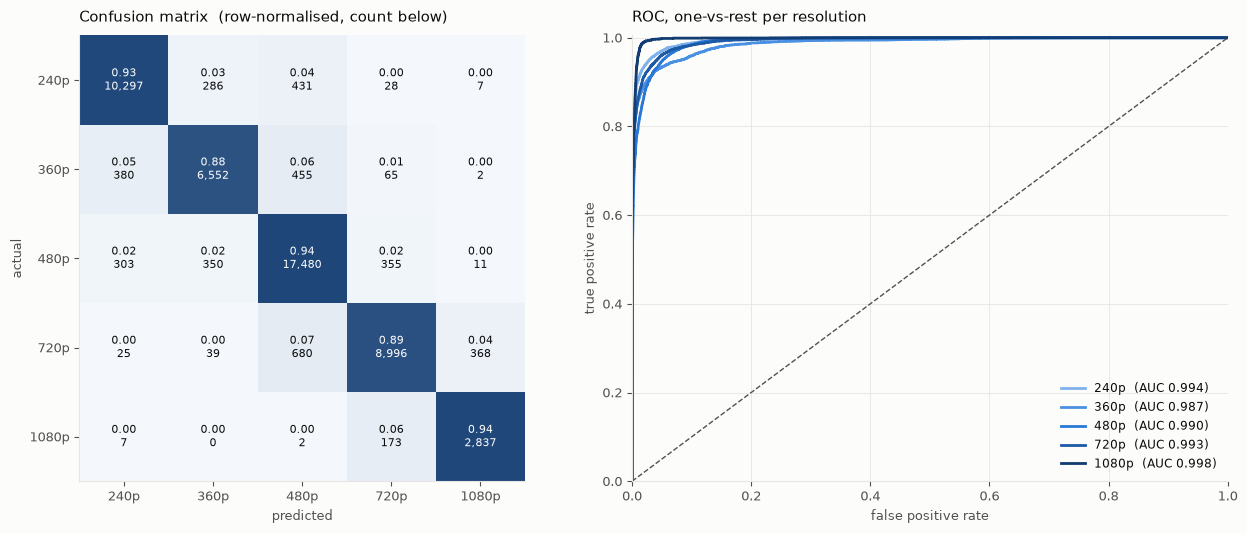

macro    OvR AUC = 0.9923
weighted OvR AUC = 0.9916


In [38]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, roc_auc_score, auc)
from sklearn.preprocessing import label_binarize
from matplotlib.colors import LinearSegmentedColormap

classes = list(tuned.classes_)                 # [240, 360, 480, 720, 1080]
y_pred  = tuned.predict(X_test)
y_proba = tuned.predict_proba(X_test)

# --- 1 & 2. accuracy and F1 ---------------------------------------------------
print(f'accuracy      {accuracy_score(y_test, y_pred):.4f}')
print(f'macro F1      {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'weighted F1   {f1_score(y_test, y_pred, average="weighted"):.4f}')
print(f'\n{classification_report(y_test, y_pred, digits=3)}')

# --- 3 & 4. confusion matrix and ROC ------------------------------------------
RAMP = ['#7fb2ec', '#4a90e2', '#2a78d6', '#1c5aa6', '#123c72']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.4),
                               gridspec_kw={'width_ratios': [1, 1.05]})

cm      = confusion_matrix(y_test, y_pred, labels=classes)
cm_norm = confusion_matrix(y_test, y_pred, labels=classes, normalize='true')

ax1.imshow(cm_norm, cmap=LinearSegmentedColormap.from_list('seq', ['#f4f8fd', '#123c72']),
           vmin=0, vmax=1)
for i in range(len(classes)):
    for j in range(len(classes)):
        ax1.text(j, i, f'{cm_norm[i, j]:.2f}\n{cm[i, j]:,}', ha='center', va='center',
                 fontsize=8, color='#fcfcfb' if cm_norm[i, j] > .5 else INK)
ax1.set_xticks(range(len(classes))), ax1.set_xticklabels([f'{c}p' for c in classes])
ax1.set_yticks(range(len(classes))), ax1.set_yticklabels([f'{c}p' for c in classes])
ax1.set_xlabel('predicted'), ax1.set_ylabel('actual')
ax1.set_title('Confusion matrix  (row-normalised, count below)', loc='left', fontsize=11, pad=10)
ax1.grid(False)

y_bin = label_binarize(y_test, classes=classes)
for k, (cls, colour) in enumerate(zip(classes, RAMP)):
    fpr, tpr, _ = roc_curve(y_bin[:, k], y_proba[:, k])
    ax2.plot(fpr, tpr, color=colour, lw=2, label=f'{cls}p  (AUC {auc(fpr, tpr):.3f})')
ax2.plot([0, 1], [0, 1], color=INK2, lw=1, ls='--')
ax2.set_xlim(0, 1), ax2.set_ylim(0, 1.005)
ax2.set_xlabel('false positive rate'), ax2.set_ylabel('true positive rate')
ax2.set_title('ROC, one-vs-rest per resolution', loc='left', fontsize=11, pad=10)
ax2.legend(frameon=False, fontsize=8.5, loc='lower right')
ax2.grid(True), ax2.set_axisbelow(True)

plt.tight_layout(), plt.show()

print(f'macro    OvR AUC = {roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro"):.4f}')
print(f'weighted OvR AUC = {roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted"):.4f}')

class_weight='balanced' did its job on 1080p. Recall 0.940 — the highest of any class — despite 1080p being only 6% of rows. But look at its precision: 0.880, the lowest. The weighting made the model eager to call 1080p, so it over-predicts it slightly. 

#### Precision-Recall

The assignment asks for ROC/AUC, and the curves above are the standard answer. They are
also the flattering one, and it is worth adding the precision-recall view alongside them.

In a one-vs-rest reading of 1080p, the negatives are every row of the other four 
resolutions — roughly 94% of the test set. That denominator is so large that a substantial number of false 1080p
predictions still moves the FPR only slightly.

Precision and recall never use TN.

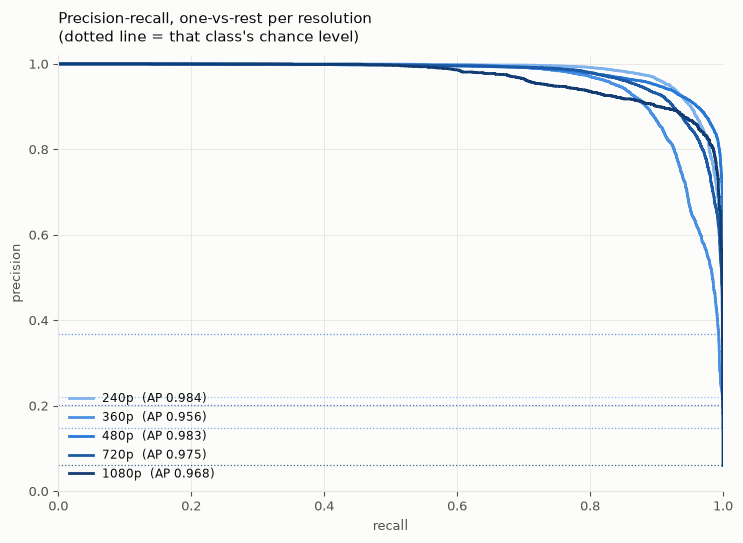

            support  chance      AP     lift
resolution                                  
240           11049  0.2204  0.9836   4.4627
360            7454  0.1487  0.9565   6.4322
480           18499  0.3690  0.9834   2.6649
720           10108  0.2016  0.9753   4.8367
1080           3019  0.0602  0.9676  16.0662

macro AP   0.9733
micro AP   0.9768


In [39]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_bin = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
rows = []
for k, (cls, colour) in enumerate(zip(classes, RAMP)):
    prec, rec, _ = precision_recall_curve(y_bin[:, k], y_proba[:, k])
    ap     = average_precision_score(y_bin[:, k], y_proba[:, k])
    chance = y_bin[:, k].mean()
    ax.plot(rec, prec, color=colour, lw=2, label=f'{cls}p  (AP {ap:.3f})')
    ax.axhline(chance, color=colour, lw=.9, ls=':', alpha=.8)
    rows.append({'resolution': cls, 'support': int(y_bin[:, k].sum()),
                 'chance': chance, 'AP': ap, 'lift': ap / chance})

ax.set_xlim(0, 1), ax.set_ylim(0, 1.02)
ax.set_xlabel('recall'), ax.set_ylabel('precision')
ax.set_title('Precision-recall, one-vs-rest per resolution\n'
             '(dotted line = that class\'s chance level)', loc='left', fontsize=11, pad=10)
ax.legend(frameon=False, fontsize=8.5, loc='lower left')
ax.grid(True), ax.set_axisbelow(True)
plt.tight_layout(), plt.show()

ap_table = pd.DataFrame(rows).set_index('resolution')
print(ap_table.round(4).to_string())
print(f'\nmacro AP   {ap_table["AP"].mean():.4f}')
print(f'micro AP   {average_precision_score(y_bin, y_proba, average="micro"):.4f}')

## Part 3: Predict the Ongoing Resolution of a Real Netflix Session

Now that you have your model, it's time to put it in practice!

Use a preprocessed Netflix video session to infer **and plot** the resolution at 10-second time intervals.

A real Netflix session from the *held-out test split* is
used. `video_position` is already sampled every 10 seconds (10 s ... 720 s), so one
row is exactly one 10-second interval.

Resolution is drawn as an evenly spaced ordinal ladder. 

/var/folders/w4/c7srzhyx44v_rr22dd7ncd480000gn/T/ipykernel_19891/4186069292.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_session = netflix_sessions.groupby('session').apply(


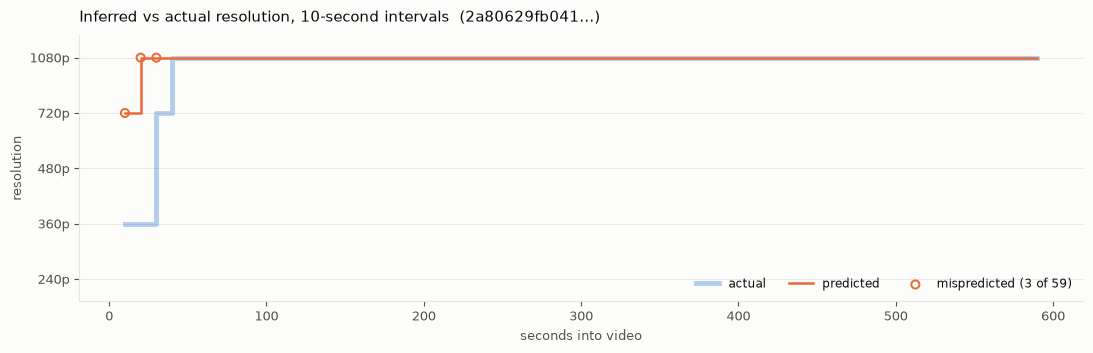

(None, None)

In [42]:
timeline = pd.DataFrame({
    'session': session_groups.iloc[test_idx].values,
    'service': clean['service'].iloc[test_idx].values,
    'position': clean['video_position'].iloc[test_idx].values,
    'actual':   y_test.values,
    'predicted': y_pred,
})
netflix_sessions = timeline[timeline['service'] == 'netflix']

per_session = netflix_sessions.groupby('session').apply(
    lambda d: pd.Series({'n': len(d), 'n_res': d['actual'].nunique(),
                         'accuracy': (d['actual'] == d['predicted']).mean()}))

median_acc = per_session['accuracy'].median()
eligible = per_session[(per_session['n_res'] >= 3) & (per_session['n'] >= 40)]
chosen = (eligible['accuracy'] - median_acc).abs().idxmin()

session = netflix_sessions[netflix_sessions['session'] == chosen].sort_values('position')
# --- plot ---------------------------------------------------------------------
ladder = {r: i for i, r in enumerate(classes)}
fig, ax = plt.subplots(figsize=(11, 3.6))

ax.step(session['position'], session['actual'].map(ladder), where='post',
        color=BLUE, lw=3.5, alpha=.35, label='actual')
ax.step(session['position'], session['predicted'].map(ladder), where='post',
        color=ORANGE, lw=1.8, label='predicted')

miss = session[session['actual'] != session['predicted']]
ax.scatter(miss['position'], miss['predicted'].map(ladder), s=34, facecolor='none',
           edgecolor=ORANGE, lw=1.4, zorder=5,
           label=f'mispredicted ({len(miss)} of {len(session)})')

ax.set_yticks(range(len(classes))), ax.set_yticklabels([f'{c}p' for c in classes])
ax.set_ylim(-.4, len(classes) - .6)
ax.set_xlabel('seconds into video'), ax.set_ylabel('resolution')
ax.set_title(f'Inferred vs actual resolution, 10-second intervals  ({chosen[:12]}...)',
             loc='left', fontsize=11, pad=10)
ax.legend(frameon=False, fontsize=8.5, ncol=3, loc='lower right')
ax.grid(axis='y'), ax.set_axisbelow(True)
plt.tight_layout(), plt.show()

The plot shows 360p at startup, ramping up to 720p and 1080p by 40 s, then a flat for the remaining nine minutes. All 3 errors are in the first 30 seconds when the model calls the ramp one rung early and reaches 1080p at 20 s.

That failure is consistent with the confusion matrix: errors cluster at transitions, not during steady playback.

### Extra: Drawbacks of the HistGradientBoosting model

`RandomForestClassifier`
classifiers provide `feature_importances_` after fitting; scikit-learn's
`HistGradientBoostingClassifier` does not implement that attribute. 

Each feature is bucketed into at most
255 bins before the split search. That is what makes training fast, but it means split
thresholds are approximations of the true cut points. On a bitrate ladder, where the real
boundaries are specific chunk sizes, a threshold that lands mid-bin is a small permanent
error the model cannot recover from.


In [41]:
from sklearn.inspection import permutation_importance

# --- an interpretable model on the identical split and features ---------------
rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=2,
                            class_weight='balanced', n_jobs=-1, random_state=SEED)
t0 = time.time()
rf.fit(X_train, y_train)
rf_fit_time = time.time() - t0

rf_pred = rf.predict(X_test)
hgb_pred = tuned.predict(X_test)

comparison = pd.DataFrame({
    'HistGB': [accuracy_score(y_test, hgb_pred),
               f1_score(y_test, hgb_pred, average='macro'),
               f1_score(y_test, hgb_pred, average='weighted')],
    'RandomForest': [accuracy_score(y_test, rf_pred),
                     f1_score(y_test, rf_pred, average='macro'),
                     f1_score(y_test, rf_pred, average='weighted')],
}, index=['accuracy', 'macro F1', 'weighted F1'])
print(comparison.round(4).to_string())
print(f'\nRandomForest fit time   {rf_fit_time:.1f}s')
print(f'prediction agreement    {(rf_pred == hgb_pred).mean():.4f}')

# --- do the two models rank the features the same way? ------------------------
# RandomForest exposes feature_importances_ directly; HistGB has no such attribute,
# so its importances must be obtained by permutation on held-out rows.
rf_imp = pd.Series(rf.feature_importances_, index=X_train.columns)

sub = np.random.RandomState(SEED).choice(len(X_test), 20_000, replace=False)
perm = permutation_importance(tuned, X_test.iloc[sub], y_test.iloc[sub],
                              scoring='f1_macro', n_repeats=3,
                              random_state=SEED, n_jobs=-1)
hgb_imp = pd.Series(perm.importances_mean, index=X_test.columns)

ranks = pd.DataFrame({
    'rf_rank':  rf_imp.rank(ascending=False).astype(int),
    'rf_imp':   rf_imp.round(4),
    'hgb_rank': hgb_imp.rank(ascending=False).astype(int),
    'hgb_imp':  hgb_imp.round(4),
}).sort_values('rf_rank')

print(f'\ntop 15 features by RandomForest importance:\n{ranks.head(15).to_string()}')

TOP_K = 15
overlap = set(rf_imp.nlargest(TOP_K).index) & set(hgb_imp.nlargest(TOP_K).index)
print(f'\ntop-{TOP_K} overlap          {len(overlap)} of {TOP_K}')
print(f'Spearman rank corr      {rf_imp.corr(hgb_imp, method="spearman"):.4f}')

# --- per-class agreement ------------------------------------------------------
per_class = pd.DataFrame({
    'HistGB recall': [((hgb_pred == c) & (y_test == c)).sum() / (y_test == c).sum()
                      for c in classes],
    'RF recall':     [((rf_pred == c) & (y_test == c)).sum() / (y_test == c).sum()
                      for c in classes],
}, index=[f'{c}p' for c in classes])
print(f'\n{per_class.round(4).to_string()}')

             HistGB  RandomForest
accuracy     0.9209        0.9153
macro F1     0.9156        0.9089
weighted F1  0.9207        0.9149

RandomForest fit time   20.8s
prediction agreement    0.9594

top 15 features by RandomForest importance:
                                  rf_rank  rf_imp  hgb_rank  hgb_imp
L7_allprev_chunksizes_50                1  0.0535         2   0.0200
L7_allprev_max_chunksize                2  0.0495         1   0.0498
L7_10_avg_chunksize                     3  0.0446        32   0.0013
L7_10_chunksizes_85                     4  0.0400        34   0.0011
L7_allprev_avg_chunksize                5  0.0392        11   0.0093
L7_10_chunksizes_90                     6  0.0386        31   0.0014
L4_userAvgRwnd                          7  0.0358        17   0.0035
L7_10_max_chunksize                     8  0.0328        19   0.0032
L7_allprev_std_chunksize                9  0.0323         6   0.0125
L3_service_Video_throughput_down       10  0.0322        12   0.007

Interestingly, this ranking order is a little different than the AUC top-40 feature selection above. Perhaps this means the trimming of features should be systematically tested (as a parameter to be tuned).